# Sentiment Analysis of Application Reviews

In [1]:
# Enable legacy Keras compatibility for BERT models

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
# Install required compatible packages

!pip install transformers==4.40.1 tf-keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 64.9 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the fol

In [3]:
# Install KaggleHub to access the dataset directly from Kaggle
!pip install kagglehub[pandas-datasets]

# Import Required Libraries

In [4]:
# Import required libraries for data analysis and preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Dataset Loading

In [5]:
# Download the Google Play Store Reviews dataset
import kagglehub

path = kagglehub.dataset_download(
    "prakharrathi25/google-play-store-reviews"
)

print("Dataset Path:", path)

100%|██████████| 2.55M/2.55M [00:00<00:00, 4.07MB/s]

Extracting files...
Dataset Path: /root/.cache/kagglehub/datasets/prakharrathi25/google-play-store-reviews/versions/1


In [6]:
# Display the files available in the downloaded dataset
import os

print(os.listdir(path))

['reviews.csv']


In [7]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv(f"{path}/reviews.csv")

df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo


# Exploratory Data Analysis (EDA)

In [8]:
# Display the number of rows and columns in the dataset
df.shape

(12495, 12)

In [9]:
# Display general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12495 entries, 0 to 12494
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              12495 non-null  object
 1   userName              12495 non-null  object
 2   userImage             12495 non-null  object
 3   content               12495 non-null  object
 4   score                 12495 non-null  int64 
 5   thumbsUpCount         12495 non-null  int64 
 6   reviewCreatedVersion  10333 non-null  object
 7   at                    12495 non-null  object
 8   replyContent          5818 non-null   object
 9   repliedAt             5818 non-null   object
 10  sortOrder             12495 non-null  object
 11  appId                 12495 non-null  object
dtypes: int64(2), object(10)
memory usage: 1.1+ MB


In [10]:
# Display the dataset column names
df.columns

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'sortOrder', 'appId'],
      dtype='object')

In [11]:
# Check for missing values in each column
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,2162
at,0
replyContent,6677
repliedAt,6677


In [12]:
# Display the distribution of rating scores
df['score'].value_counts()

,count
score,
5,2879
4,2775
1,2506
2,2344
3,1991


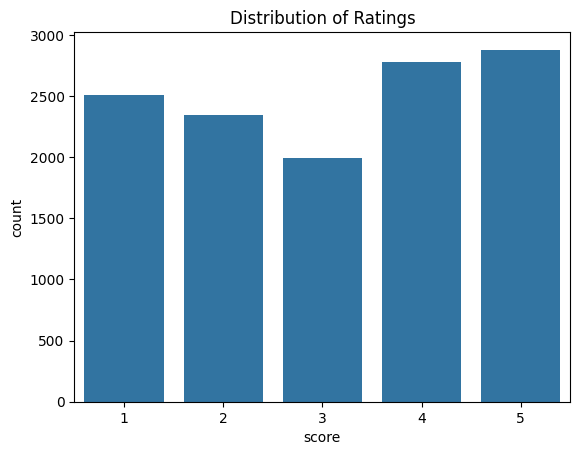

In [13]:
# Visualize the distribution of review ratings
sns.countplot(x='score', data=df)

plt.title("Distribution of Ratings")

plt.show()

# Sentiment Labeling

In [14]:
# Convert rating scores into sentiment categories
def convert_sentiment(rating):

    if rating <= 2:
        return "Negative"

    elif rating == 3:
        return "Neutral"

    else:
        return "Positive"

In [15]:
# Create a new column for sentiment labels
df['sentiment'] = df['score'].apply(convert_sentiment)

In [16]:
# Display sample sentiment labels
df[['content', 'score', 'sentiment']].head()

,content,score,sentiment
0,I cannot open the app anymore,1,Negative
1,I have been begging for a refund from this app...,1,Negative
2,Very costly for the premium version (approx In...,1,Negative
3,"Used to keep me organized, but all the 2020 UP...",1,Negative
4,Dan Birthday Oct 28,1,Negative


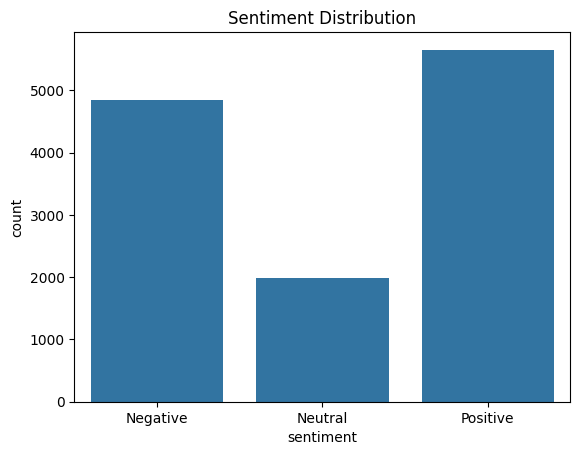

In [17]:
# Visualize the distribution of sentiment classes
sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")

plt.show()

# Data Preprocessing

In [18]:
# Keep only the columns needed for sentiment analysis
df = df[['content', 'score', 'sentiment']]

In [19]:
# Remove rows with missing values
df.dropna(inplace=True)

In [20]:
# Remove duplicate reviews
df.drop_duplicates(inplace=True)

In [21]:
# Convert all review text to lowercase
df['content'] = df['content'].str.lower()

In [22]:
# Remove URLs from review text while preserving emojis
def remove_urls(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text)

df['content'] = df['content'].apply(remove_urls)

In [23]:
# Display sample reviews after preprocessing
df[['content', 'sentiment']].head(10)

,content,sentiment
0,i cannot open the app anymore,Negative
1,i have been begging for a refund from this app...,Negative
2,very costly for the premium version (approx in...,Negative
3,"used to keep me organized, but all the 2020 up...",Negative
4,dan birthday oct 28,Negative
5,it has changed how i viewed my different lists...,Negative
6,i'm only looking for a grocery list app but ev...,Negative
7,"reset my free trial, new phone i'd like to see...",Negative
8,how do to stop monthly payment because i don't...,Negative
9,i complain about not crashes and it was immedi...,Negative


# Emoji Exploration

In [24]:
# Display reviews containing emojis or special characters for initial inspection
emoji_reviews = df[
    df['content'].str.contains(r'[^\w\s,]', regex=True)
]

emoji_reviews[['content', 'sentiment']].head(10)

,content,sentiment
2,very costly for the premium version (approx in...,Negative
3,"used to keep me organized, but all the 2020 up...",Negative
5,it has changed how i viewed my different lists...,Negative
6,i'm only looking for a grocery list app but ev...,Negative
7,"reset my free trial, new phone i'd like to see...",Negative
8,how do to stop monthly payment because i don't...,Negative
9,i complain about not crashes and it was immedi...,Negative
10,constant crashing. after reading all the negat...,Negative
11,widgets are useless because they always show a...,Negative
12,horrible app. it doesn't do as described. abso...,Negative


In [25]:
# Display examples of reviews after preprocessing
df[['content', 'score', 'sentiment']].sample(5, random_state=42)

,content,score,sentiment
3763,what an absolute boon. my boyfriend has adhd a...,5,Positive
5114,"sir , actually some time it doesn't pop remind...",2,Negative
8452,"good app. i agree with other reviews, the addi...",5,Positive
359,not a great user interface. have been using fo...,2,Negative
11822,the single franklincovey planner feature avail...,2,Negative


In [26]:
# Display the final dataset shape after preprocessing
df.shape

(11944, 3)

# Emoji-Aware vs Traditional Preprocessing

In [27]:
# Install emoji library
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 21.9 MB/s eta 0:00:00


In [28]:
# Import emoji library
import emoji

In [29]:
# Create a copy of the dataset while preserving emojis
df_with_emojis = df.copy()

In [30]:
# Create a second version of the dataset without emojis
df_without_emojis = df.copy()

In [31]:
# Remove emojis from review text
def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

In [32]:
# Apply emoji removal to the second dataset
df_without_emojis['content'] = df_without_emojis['content'].apply(remove_emojis)

In [33]:
# Count reviews that contain emojis
emoji_count = 0

for text in df['content']:
    if emoji.emoji_count(str(text)) > 0:
        emoji_count += 1

print("Number of reviews containing emojis:", emoji_count)

Number of reviews containing emojis: 597


## Example of Emoji Removal

In [34]:
# Compare a review before and after emoji removal

emoji_sample_text = None

for text in df_with_emojis['content']:
    if emoji.emoji_count(str(text)) > 0:
        emoji_sample_text = text
        break

print("With Emojis:")
print(str(emoji_sample_text))

print("\nWithout Emojis:")
print(remove_emojis(emoji_sample_text))

With Emojis:
used to keep me organized, but all the 2020 updates have made a mess of things !!! y cudn't u leave well enuf alone ??? guess ur techies feel the need to keep making changes to justify continuing to collect their salary !!! 🤤🤤🤤

Without Emojis:
used to keep me organized, but all the 2020 updates have made a mess of things !!! y cudn't u leave well enuf alone ??? guess ur techies feel the need to keep making changes to justify continuing to collect their salary !!! 


# Data Splitting

In [35]:
# Split the dataset into training (70%), validation (15%), and testing (15%) sets
from sklearn.model_selection import train_test_split

X = df_with_emojis['content']
y = df_with_emojis['sentiment']

# Split data into train and temporary sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split temporary set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (8360,)
Validation: (1792,)
Test: (1792,)


In [36]:
# Save the cleaned datasets for later use and comparison
df_with_emojis.to_csv("cleaned_reviews_with_emojis.csv", index=False)
df_without_emojis.to_csv("cleaned_reviews_without_emojis.csv", index=False)

In [37]:
# Encode sentiment labels into numerical values

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_val_encoded = encoder.transform(y_val)
y_test_encoded = encoder.transform(y_test)

print(encoder.classes_)

['Negative' 'Neutral' 'Positive']


# BERT Model with Emojis

In [38]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [39]:
# Install compatible transformers version

!pip install transformers==4.40.1

In [40]:
# Install tf-keras for compatibility
!pip install tf-keras

In [41]:
# Import BERT libraries

from transformers import BertTokenizer
from transformers import TFBertForSequenceClassification

import tensorflow as tf

In [42]:
# Load pretrained BERT tokenizer

tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [43]:
# Tokenize training texts

train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=128
)

In [44]:
# Tokenize validation texts

val_encodings = tokenizer(
    list(X_val),
    truncation=True,
    padding=True,
    max_length=128
)

In [45]:
# Tokenize testing texts

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128
)

In [46]:
# Create TensorFlow datasets

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train_encoded
))

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings),
    y_val_encoded
))

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    y_test_encoded
))

In [47]:
# Batch datasets

train_dataset = train_dataset.shuffle(1000).batch(16)

val_dataset = val_dataset.batch(16)

test_dataset = test_dataset.batch(16)

In [48]:
# Load pretrained BERT classification model

model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [49]:
# Compile the BERT model

optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-5
)

loss = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

In [50]:
def compute_gradients(batch):
    inputs = {
        "input_ids": batch[0]["input_ids"],
        "attention_mask": batch[0]["attention_mask"],
        "token_type_ids": batch[0]["token_type_ids"]
    }
    labels = batch[1]
    with tf.GradientTape() as tape:
        outputs = model(inputs, training=True)
        logits = outputs.logits
        current_loss = loss(labels, logits)
    gradients = tape.gradient(current_loss, model.trainable_variables)
    return gradients, current_loss
    #

In [51]:
# Train the BERT model

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=2
)

Epoch 1/2
523/523 [==============================] - 118s 130ms/step - loss: 0.6748 - accuracy: 0.7257 - val_loss: 0.6097 - val_accuracy: 0.7528
Epoch 2/2
523/523 [==============================] - 42s 81ms/step - loss: 0.5093 - accuracy: 0.7963 - val_loss: 0.6011 - val_accuracy: 0.7533


# BERT Model without Emojis

In [52]:
# Split the dataset into training (70%), validation (15%), and testing (15%) sets
X_no_emoji = df_without_emojis['content']
y_no_emoji = df_without_emojis['sentiment']

X_train_no, X_temp_no, y_train_no, y_temp_no = train_test_split(
    X_no_emoji, y_no_emoji,
    test_size=0.30,
    random_state=42,
    stratify=y_no_emoji
)

X_val_no, X_test_no, y_val_no, y_test_no = train_test_split(
    X_temp_no, y_temp_no,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_no
)

In [53]:
# Encode labels

y_train_no_encoded = encoder.transform(y_train_no)
y_val_no_encoded = encoder.transform(y_val_no)
y_test_no_encoded = encoder.transform(y_test_no)

print(encoder.classes_)

['Negative' 'Neutral' 'Positive']


In [54]:
# Tokenize training texts
train_no_encodings = tokenizer(
    list(X_train_no),
    truncation=True,
    padding=True,
    max_length=128
)

In [55]:
# Tokenize validation texts
val_no_encodings = tokenizer(
    list(X_val_no),
    truncation=True,
    padding=True,
    max_length=128
)

In [56]:
# Tokenize test texts
test_no_encodings = tokenizer(
    list(X_test_no),
    truncation=True,
    padding=True,
    max_length=128
)

In [57]:
# Create TensorFlow datasets with Batch

train_no_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_no_encodings),
    y_train_no_encoded
)).shuffle(1000).batch(16)

val_no_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_no_encodings),
    y_val_no_encoded
)).batch(16)

test_no_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_no_encodings),
    y_test_no_encoded
)).batch(16)

In [58]:
# Load a new BERT model for the dataset without emojis

model_no_emoji = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

optimizer_no = tf.keras.optimizers.Adam(
    learning_rate=2e-5
)

loss = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

model_no_emoji.compile(
    optimizer=optimizer_no,
    loss=loss,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [59]:
# Train BERT model without emojis

history_no_emoji = model_no_emoji.fit(
    train_no_dataset,
    validation_data=val_no_dataset,
    epochs=2
)

Epoch 1/2
523/523 [==============================] - 113s 129ms/step - loss: 0.6708 - accuracy: 0.7288 - val_loss: 0.6078 - val_accuracy: 0.7606
Epoch 2/2
523/523 [==============================] - 42s 81ms/step - loss: 0.5073 - accuracy: 0.8017 - val_loss: 0.6536 - val_accuracy: 0.7489


# Model Improvements

## Class Weight Balancing

In [60]:
# Calculate class weights to handle class imbalance

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

class_weights_dict = dict(enumerate(class_weights))

print(class_weights_dict)

{0: np.float64(0.8306010928961749), 1: np.float64(2.0520373097692683), 2: np.float64(0.764098345672242)}


In [61]:
# Load a fresh BERT model for the Class Weight Balancing experiment

class_weight_model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

# Compile the model

class_weight_optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-5
)

class_weight_loss = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

class_weight_model.compile(
    optimizer=class_weight_optimizer,
    loss=class_weight_loss,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [62]:
# Train the model using class weights

class_weight_history = class_weight_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=2,
    class_weight=class_weights_dict
)

Epoch 1/2
523/523 [==============================] - 115s 131ms/step - loss: 0.7961 - accuracy: 0.6589 - val_loss: 0.6344 - val_accuracy: 0.7422
Epoch 2/2
523/523 [==============================] - 43s 83ms/step - loss: 0.6240 - accuracy: 0.7628 - val_loss: 0.6641 - val_accuracy: 0.7193


## Batch Size Tuning

In [63]:
# Load a new BERT model for Batch Size Tuning

batch_size_model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

# Compile the model

batch_size_optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-5
)

batch_size_loss = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

batch_size_model.compile(
    optimizer=batch_size_optimizer,
    loss=batch_size_loss,
    metrics=['accuracy']
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [64]:
# Apply batch size tuning

batch_train_dataset = train_dataset.unbatch().shuffle(1000).batch(8)

batch_val_dataset = val_dataset.unbatch().batch(8)

In [65]:
# Train the BERT model using smaller batch size

batch_size_history = batch_size_model.fit(
    batch_train_dataset,
    validation_data=batch_val_dataset,
    epochs=2
)

Epoch 1/2
1045/1045 [==============================] - 148s 99ms/step - loss: 0.6647 - accuracy: 0.7281 - val_loss: 0.6144 - val_accuracy: 0.7483
Epoch 2/2
1045/1045 [==============================] - 75s 72ms/step - loss: 0.4996 - accuracy: 0.8030 - val_loss: 0.6760 - val_accuracy: 0.7556


## Learning Rate Tuning

In [66]:
# Load a new BERT model for the learning rate tuning experiment
learning_rate_model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

# Compile the model with a smaller learning rate
learning_rate_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-5
)

learning_rate_model.compile(
    optimizer=learning_rate_optimizer,
    loss=loss,
    metrics=['accuracy']
)


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [67]:
# Train the model with the tuned learning rate
learning_rate_history = learning_rate_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=2
)

Epoch 1/2
523/523 [==============================] - 113s 130ms/step - loss: 0.7131 - accuracy: 0.7022 - val_loss: 0.6374 - val_accuracy: 0.7344
Epoch 2/2
523/523 [==============================] - 44s 84ms/step - loss: 0.5372 - accuracy: 0.7868 - val_loss: 0.6519 - val_accuracy: 0.7545


## Early Stopping

In [68]:
# Define early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

# Load a new BERT model for the early stopping experiment
early_stopping_model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

# Create a new optimizer for this model
early_stopping_optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-5
)

# Compile the model
early_stopping_model.compile(
    optimizer=early_stopping_optimizer,
    loss=loss,
    metrics=['accuracy']
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [69]:
# Train the model with early stopping
early_stopping_history = early_stopping_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
523/523 [==============================] - 113s 132ms/step - loss: 0.6955 - accuracy: 0.7185 - val_loss: 0.6015 - val_accuracy: 0.7595
Epoch 2/5
523/523 [==============================] - 42s 80ms/step - loss: 0.5265 - accuracy: 0.7935 - val_loss: 0.6425 - val_accuracy: 0.7545


## Dropout Regularization

In [70]:
from transformers import BertConfig, TFBertForSequenceClassification

# Create BERT configuration with dropout
dropout_config = BertConfig.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3
)

# Load model with dropout
dropout_model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    config=dropout_config
)

# Compile model
dropout_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=loss,
    metrics=['accuracy']
)

# Train model
dropout_history = dropout_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3
523/523 [==============================] - 112s 128ms/step - loss: 0.7414 - accuracy: 0.6996 - val_loss: 0.6841 - val_accuracy: 0.7394
Epoch 2/3
523/523 [==============================] - 43s 82ms/step - loss: 0.6112 - accuracy: 0.7537 - val_loss: 0.6534 - val_accuracy: 0.7573
Epoch 3/3
523/523 [==============================] - 41s 79ms/step - loss: 0.5739 - accuracy: 0.7691 - val_loss: 0.6589 - val_accuracy: 0.7623


## ReduceLROnPlateau

In [71]:
# Reduce learning rate automatically when validation loss stops improving
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-7
)

# Load fresh BERT model
reduce_lr_model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

# Compile model
reduce_lr_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=loss,
    metrics=['accuracy']
)

# Train model with ReduceLROnPlateau
reduce_lr_history = reduce_lr_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=[reduce_lr]
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
523/523 [==============================] - 111s 128ms/step - loss: 0.6953 - accuracy: 0.7203 - val_loss: 0.6487 - val_accuracy: 0.7383 - lr: 2.0000e-05
Epoch 2/5
523/523 [==============================] - 44s 83ms/step - loss: 0.5322 - accuracy: 0.7897 - val_loss: 0.6399 - val_accuracy: 0.7556 - lr: 2.0000e-05
Epoch 3/5
523/523 [==============================] - 41s 77ms/step - loss: 0.4112 - accuracy: 0.8419 - val_loss: 0.7388 - val_accuracy: 0.7422 - lr: 2.0000e-05
Epoch 4/5
523/523 [==============================] - 40s 77ms/step - loss: 0.2453 - accuracy: 0.9147 - val_loss: 0.8954 - val_accuracy: 0.7316 - lr: 1.0000e-05
Epoch 5/5
523/523 [==============================] - 40s 77ms/step - loss: 0.1435 - accuracy: 0.9533 - val_loss: 1.0197 - val_accuracy: 0.7260 - lr: 5.0000e-06


## Gradient Clipping

In [72]:
# Clear memory before training this model

import gc
import tensorflow as tf

tf.keras.backend.clear_session()
gc.collect()

print("Memory cleared before Gradient Clipping.")

Memory cleared before Gradient Clipping.


In [73]:
# Load a fresh BERT model for the Gradient Clipping experiment

clip_model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

# Create optimizer with Gradient Clipping enabled

clip_optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-5,
    clipnorm=1.0
)

# Compile the model

clip_model.compile(
    optimizer=clip_optimizer,
    loss=loss,
    metrics=['accuracy']
)

# Train the model using Gradient Clipping

print("Training BERT model with Gradient Clipping...")

clip_history = clip_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=2
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training BERT model with Gradient Clipping...
Epoch 1/2
523/523 [==============================] - 129s 150ms/step - loss: 0.6784 - accuracy: 0.7237 - val_loss: 0.6125 - val_accuracy: 0.7511
Epoch 2/2
523/523 [==============================] - 54s 103ms/step - loss: 0.5159 - accuracy: 0.7970 - val_loss: 0.6202 - val_accuracy: 0.7589


## RMSprop Optimizer

In [74]:
# Load a fresh BERT model for the RMSprop optimizer experiment

rmsprop_model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

# Create RMSprop optimizer instead of Adam

rmsprop_optimizer = tf.keras.optimizers.RMSprop(
    learning_rate=2e-5
)

# Compile the model

rmsprop_model.compile(
    optimizer=rmsprop_optimizer,
    loss=loss,
    metrics=['accuracy']
)

# Train the model using RMSprop optimizer

print("Training BERT model with RMSprop optimizer...")

rmsprop_history = rmsprop_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=2
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training BERT model with RMSprop optimizer...
Epoch 1/2
523/523 [==============================] - 90s 107ms/step - loss: 0.6919 - accuracy: 0.7194 - val_loss: 0.6050 - val_accuracy: 0.7617
Epoch 2/2
523/523 [==============================] - 39s 75ms/step - loss: 0.5403 - accuracy: 0.7837 - val_loss: 0.6494 - val_accuracy: 0.7400


## Max Sequence Length Tuning

In [75]:
# Tokenize texts with a different max sequence length

train_encodings_256 = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings_256 = tokenizer(
    list(X_val),
    truncation=True,
    padding=True,
    max_length=256
)

# Create TensorFlow datasets

train_dataset_256 = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings_256),
    y_train_encoded
)).shuffle(1000).batch(16)

val_dataset_256 = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings_256),
    y_val_encoded
)).batch(16)

# Load a fresh BERT model

sequence_length_model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

# Compile model

sequence_length_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=2e-5
    ),
    loss=loss,
    metrics=['accuracy']
)

# Train model

sequence_length_history = sequence_length_model.fit(
    train_dataset_256,
    validation_data=val_dataset_256,
    epochs=2
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/2
523/523 [==============================] - 132s 163ms/step - loss: 0.6865 - accuracy: 0.7211 - val_loss: 0.6020 - val_accuracy: 0.7589
Epoch 2/2
523/523 [==============================] - 62s 119ms/step - loss: 0.5172 - accuracy: 0.7932 - val_loss: 0.6422 - val_accuracy: 0.7366


## Learning Rate Scheduler

In [76]:
# Create learning rate scheduler

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 2e-5 * (0.5 ** epoch)
)

# Load a fresh BERT model

scheduler_model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

# Compile model

scheduler_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=2e-5
    ),
    loss=loss,
    metrics=['accuracy']
)

# Train model with scheduler

scheduler_history = scheduler_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3,
    callbacks=[lr_scheduler]
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3
523/523 [==============================] - 113s 131ms/step - loss: 0.6821 - accuracy: 0.7233 - val_loss: 0.6160 - val_accuracy: 0.7511 - lr: 2.0000e-05
Epoch 2/3
523/523 [==============================] - 43s 81ms/step - loss: 0.4986 - accuracy: 0.8049 - val_loss: 0.6309 - val_accuracy: 0.7561 - lr: 1.0000e-05
Epoch 3/3
523/523 [==============================] - 41s 78ms/step - loss: 0.3895 - accuracy: 0.8561 - val_loss: 0.6846 - val_accuracy: 0.7539 - lr: 5.0000e-06


# BERT with Emojis Evaluation


In [77]:
# Import evaluation libraries

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import label_binarize

## Predictions

In [78]:
# Generate predictions using the baseline BERT model with emojis

y_pred_logits = model.predict(test_dataset).logits

# Convert logits into predicted class labels
y_pred = np.argmax(y_pred_logits, axis=1)

# True labels
y_true = y_test_encoded

# Display sample predictions
print("Sample Predictions:")
print(y_pred[:10])

112/112 [==============================] - 6s 28ms/step
Sample Predictions:
[2 2 2 2 0 0 0 0 1 0]


## Evaluation Metrics

In [79]:
# Evaluation Metrics for BERT with Emojis

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.7483258928571429
Precision: 0.7096104554960407
Recall: 0.7483258928571429
F1-Score: 0.7180473045653069


## Classification Report

In [80]:
# Classification Report

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=encoder.classes_
))


Classification Report:

              precision    recall  f1-score   support

    Negative       0.73      0.87      0.80       720
     Neutral       0.37      0.14      0.20       291
    Positive       0.81      0.86      0.84       781

    accuracy                           0.75      1792
   macro avg       0.64      0.62      0.61      1792
weighted avg       0.71      0.75      0.72      1792



## Confusion Matrix

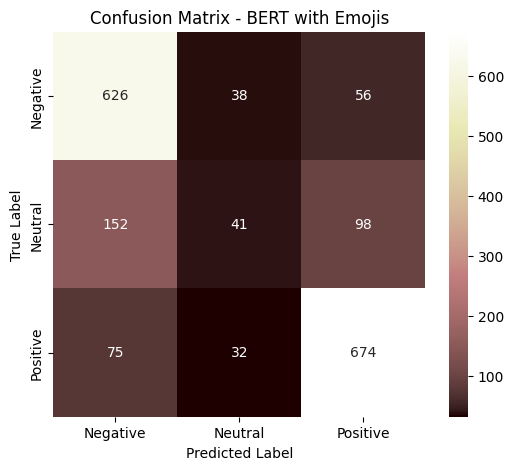

In [81]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='pink',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BERT with Emojis")

plt.show()

## Emoji-Based Evaluation


In [82]:
import emoji
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report

# Create a boolean mask for test reviews that contain emojis
emoji_mask = X_test.apply(
    lambda x: any(char in emoji.EMOJI_DATA for char in str(x))
).to_numpy()

# Select only test reviews that contain emojis
emoji_test_reviews = X_test[emoji_mask]

# Get matching labels using the boolean mask
emoji_test_labels = y_test_encoded[emoji_mask]

print("Number of emoji reviews in the test set:", len(emoji_test_reviews))

# Tokenize emoji-containing reviews
emoji_test_encodings = tokenizer(
    emoji_test_reviews.tolist(),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='tf'
)

# Create TensorFlow dataset
emoji_test_dataset = tf.data.Dataset.from_tensor_slices(
    dict(emoji_test_encodings)
).batch(16)

# Generate predictions using the BERT model trained with emojis
emoji_pred_logits = model.predict(emoji_test_dataset).logits

# Convert logits to class predictions
emoji_pred = np.argmax(emoji_pred_logits, axis=1)

# Evaluate performance on emoji-containing reviews only
print("\nEmoji Review Accuracy:")
print(accuracy_score(emoji_test_labels, emoji_pred))

print("\nEmoji Classification Report:\n")
print(classification_report(
    emoji_test_labels,
    emoji_pred,
    target_names=encoder.classes_
))

Number of emoji reviews in the test set: 97
7/7 [==============================] - 3s 34ms/step

Emoji Review Accuracy:
0.8144329896907216

Emoji Classification Report:

              precision    recall  f1-score   support

    Negative       0.73      0.79      0.76        24
     Neutral       1.00      0.09      0.17        11
    Positive       0.84      0.95      0.89        62

    accuracy                           0.81        97
   macro avg       0.86      0.61      0.61        97
weighted avg       0.83      0.81      0.78        97



## ROC Curve & AUC Score

112/112 [==============================] - 3s 28ms/step


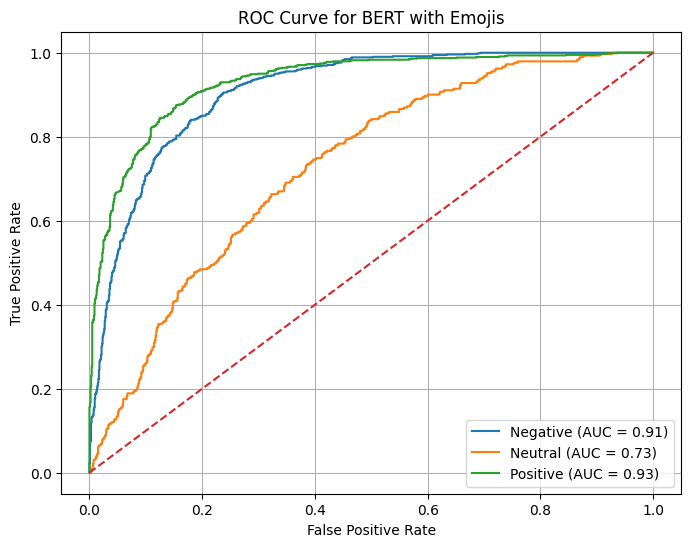

In [83]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Generate predictions for BERT with emojis
predictions = model.predict(test_dataset)

# Get prediction probabilities
y_prob = tf.nn.softmax(predictions.logits, axis=1).numpy()

# Convert labels to binary format
y_test_bin = label_binarize(
    y_test_encoded,
    classes=np.arange(len(encoder.classes_))
)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i in range(len(encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{encoder.classes_[i]} (AUC = {roc_auc:.2f})'
    )

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for BERT with Emojis')
plt.legend()
plt.grid(True)
plt.show()

## Training and Validation Accuracy

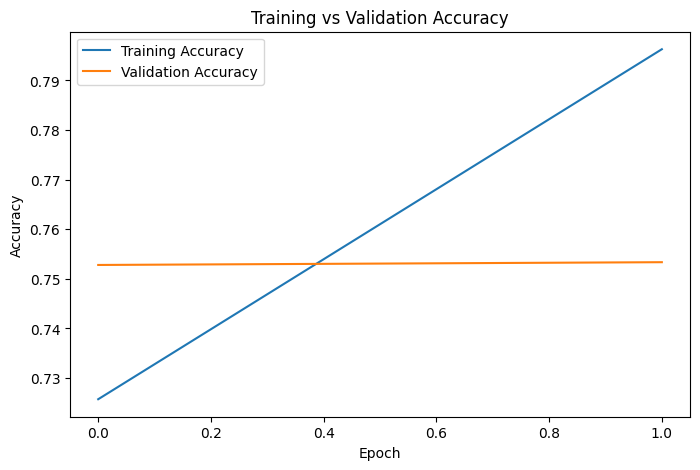

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

## Training and Validation Loss

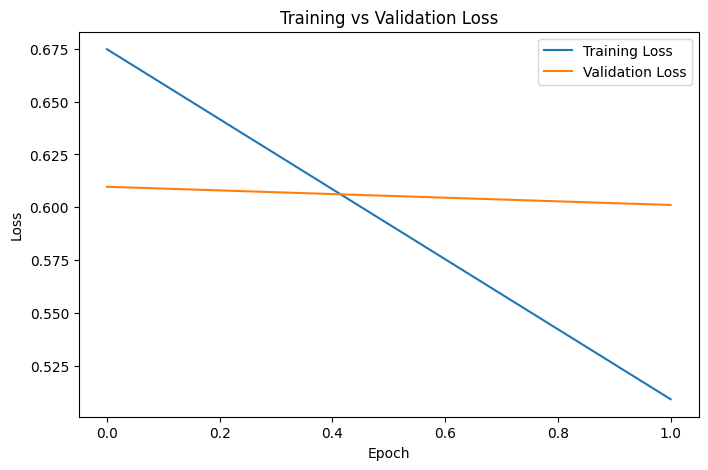

In [85]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

## Final Evaluation Summary

In [86]:
print("Final Evaluation Results - BERT with Emojis")

print("--------------------------------")

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1-Score  : {f1:.4f}")

Final Evaluation Results - BERT with Emojis
--------------------------------
Accuracy  : 0.7483
Precision : 0.7096
Recall    : 0.7483
F1-Score  : 0.7180


# BERT Without Emojis Evaluation

## Predictions

In [87]:
# Generate predictions using the model trained without emojis

y_pred_logits_no_emoji = model_no_emoji.predict(
    test_no_dataset
).logits

# Convert logits to predicted class indices

y_pred_no_emoji = np.argmax(
    y_pred_logits_no_emoji,
    axis=1
)

# True labels

y_true_no_emoji = y_test_no_encoded

# Display sample predictions

print("Sample Predictions - Without Emojis:")

print(y_pred_no_emoji[:10])

112/112 [==============================] - 6s 29ms/step
Sample Predictions - Without Emojis:
[2 2 2 2 0 0 0 0 1 1]


## Evaluation Metrics

In [88]:
# Evaluation Metrics for BERT without Emojis


accuracy_no_emoji = accuracy_score(
    y_true_no_emoji,
    y_pred_no_emoji
)

precision_no_emoji = precision_score(
    y_true_no_emoji,
    y_pred_no_emoji,
    average='weighted'
)

recall_no_emoji = recall_score(
    y_true_no_emoji,
    y_pred_no_emoji,
    average='weighted'
)

f1_no_emoji = f1_score(
    y_true_no_emoji,
    y_pred_no_emoji,
    average='weighted'
)

print("Accuracy:", accuracy_no_emoji)
print("Precision:", precision_no_emoji)
print("Recall:", recall_no_emoji)
print("F1-Score:", f1_no_emoji)

Accuracy: 0.7466517857142857
Precision: 0.7122259282820426
Recall: 0.7466517857142857
F1-Score: 0.7203075768307264


## Classification Report - Without Emojis

In [89]:
# Classification Report - Without Emojis

print("\nClassification Report - Without Emojis:\n")

print(classification_report(
    y_true_no_emoji,
    y_pred_no_emoji,
    target_names=encoder.classes_
))


Classification Report - Without Emojis:

              precision    recall  f1-score   support

    Negative       0.79      0.79      0.79       720
     Neutral       0.38      0.17      0.24       291
    Positive       0.77      0.92      0.83       781

    accuracy                           0.75      1792
   macro avg       0.64      0.63      0.62      1792
weighted avg       0.71      0.75      0.72      1792



## Confusion Matrix - Without Emojis

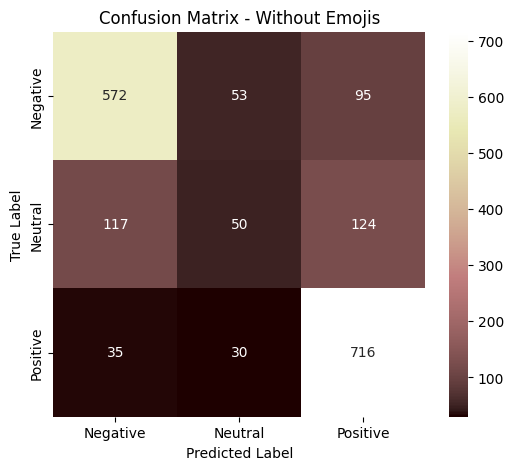

In [90]:
# Create confusion matrix

cm_no_emoji = confusion_matrix(
    y_true_no_emoji,
    y_pred_no_emoji
)

# Plot confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_no_emoji,
    annot=True,
    fmt='d',
    cmap='pink',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix - Without Emojis")

plt.show()

## Training and Validation Accuracy

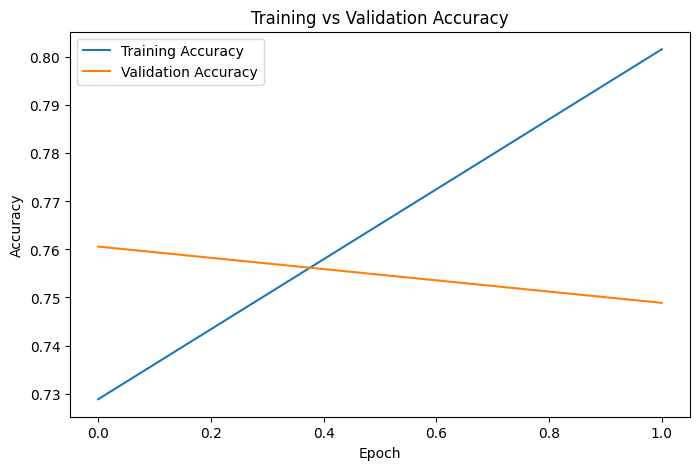

In [91]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_no_emoji.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_no_emoji.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

## Training and Validation Loss

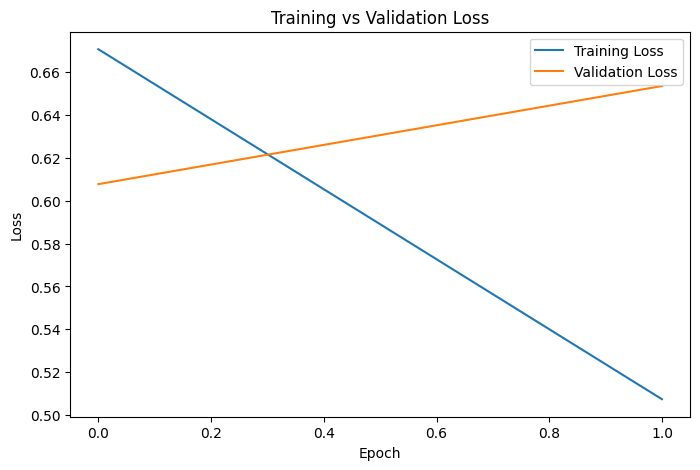

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_no_emoji.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_no_emoji.history['val_loss'],
    label='Validation Loss'
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

## Final Evaluation Summary - Without Emojis

In [93]:
print("Final Model Evaluation Results - Without Emojis")

print("------------------------------------------------")

print(f"Accuracy  : {accuracy_no_emoji:.4f}")

print(f"Precision : {precision_no_emoji:.4f}")

print(f"Recall    : {recall_no_emoji:.4f}")

print(f"F1-Score  : {f1_no_emoji:.4f}")

Final Model Evaluation Results - Without Emojis
------------------------------------------------
Accuracy  : 0.7467
Precision : 0.7122
Recall    : 0.7467
F1-Score  : 0.7203


# Improved BERT Models With Emojis Evaluation

## Evaluation Function

In [94]:
# Define a reusable evaluation function for improved models

def evaluate_improved_model(model, test_data, y_true, model_name):

    print(f"========== {model_name} ==========\n")

    # Generate predictions
    y_pred_logits = model.predict(test_data).logits
    y_pred = np.argmax(y_pred_logits, axis=1)

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    # Print evaluation metrics
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}\n")

    # Print classification report
    print("Classification Report:\n")
    print(classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    ))

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='pink',
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

## Evaluation for All Improved Models

========== BERT - Class Weight Balancing ==========

112/112 [==============================] - 6s 28ms/step
Accuracy  : 0.7037
Precision : 0.7396
Recall    : 0.7037
F1-Score  : 0.7187

Classification Report:

              precision    recall  f1-score   support

    Negative       0.78      0.76      0.77       720
     Neutral       0.29      0.40      0.34       291
    Positive       0.87      0.77      0.82       781

    accuracy                           0.70      1792
   macro avg       0.65      0.64      0.64      1792
weighted avg       0.74      0.70      0.72      1792



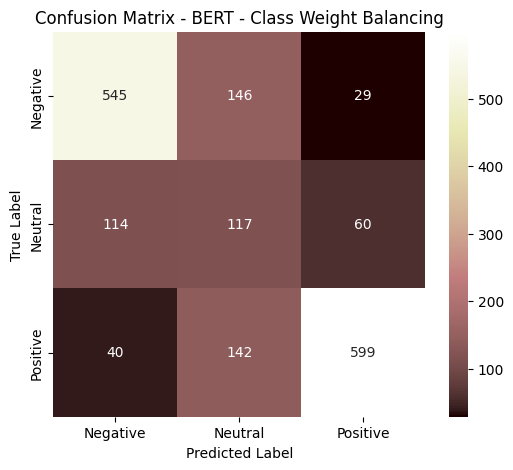

========== BERT - Batch Size Tuning ==========

112/112 [==============================] - 6s 28ms/step
Accuracy  : 0.7427
Precision : 0.7101
Recall    : 0.7427
F1-Score  : 0.7203

Classification Report:

              precision    recall  f1-score   support

    Negative       0.73      0.86      0.79       720
     Neutral       0.32      0.16      0.22       291
    Positive       0.84      0.85      0.84       781

    accuracy                           0.74      1792
   macro avg       0.63      0.62      0.62      1792
weighted avg       0.71      0.74      0.72      1792



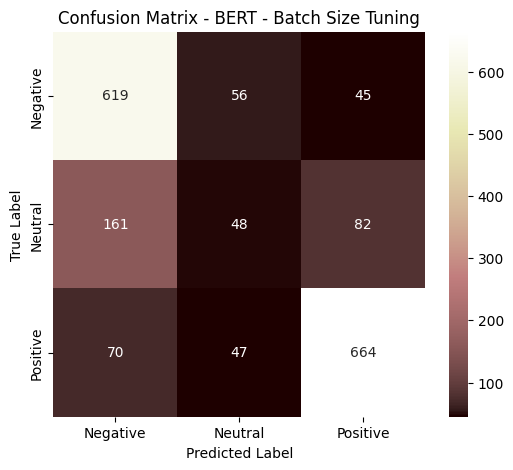

========== BERT - Learning Rate Tuning ==========

112/112 [==============================] - 6s 28ms/step
Accuracy  : 0.7455
Precision : 0.6985
Recall    : 0.7455
F1-Score  : 0.6990

Classification Report:

              precision    recall  f1-score   support

    Negative       0.77      0.81      0.79       720
     Neutral       0.40      0.07      0.12       291
    Positive       0.75      0.93      0.83       781

    accuracy                           0.75      1792
   macro avg       0.64      0.61      0.58      1792
weighted avg       0.70      0.75      0.70      1792



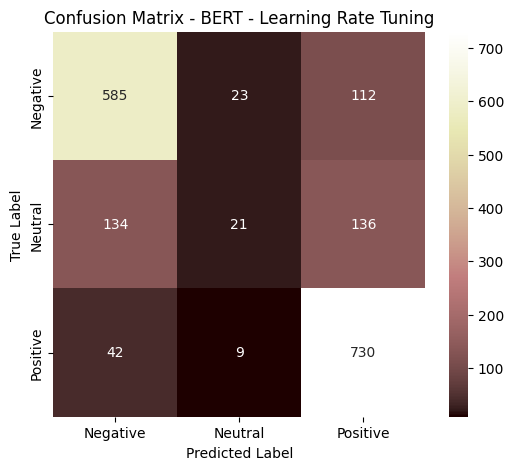

========== BERT - Early Stopping ==========

112/112 [==============================] - 6s 28ms/step
Accuracy  : 0.7450
Precision : 0.6806
Recall    : 0.7450
F1-Score  : 0.6914

Classification Report:

              precision    recall  f1-score   support

    Negative       0.76      0.82      0.79       720
     Neutral       0.30      0.04      0.07       291
    Positive       0.75      0.94      0.83       781

    accuracy                           0.74      1792
   macro avg       0.60      0.60      0.56      1792
weighted avg       0.68      0.74      0.69      1792



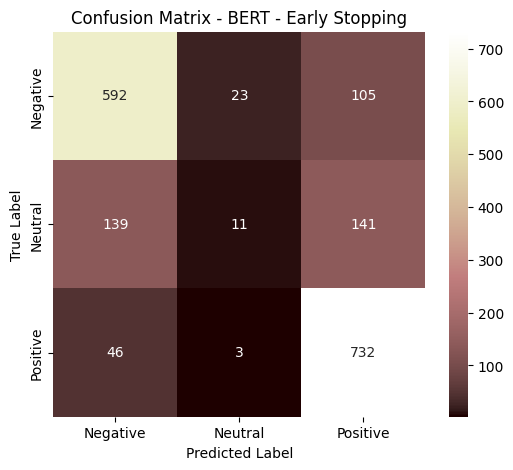

========== BERT - Dropout Regularization ==========

112/112 [==============================] - 6s 28ms/step
Accuracy  : 0.7533
Precision : 0.7165
Recall    : 0.7533
F1-Score  : 0.7258

Classification Report:

              precision    recall  f1-score   support

    Negative       0.79      0.82      0.80       720
     Neutral       0.38      0.16      0.23       291
    Positive       0.78      0.91      0.84       781

    accuracy                           0.75      1792
   macro avg       0.65      0.63      0.62      1792
weighted avg       0.72      0.75      0.73      1792



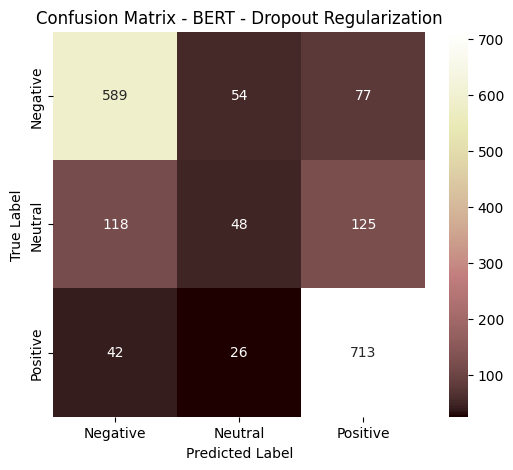

========== BERT - ReduceLROnPlateau ==========

112/112 [==============================] - 6s 27ms/step
Accuracy  : 0.7277
Precision : 0.7293
Recall    : 0.7277
F1-Score  : 0.7283

Classification Report:

              precision    recall  f1-score   support

    Negative       0.79      0.76      0.77       720
     Neutral       0.33      0.34      0.34       291
    Positive       0.82      0.85      0.83       781

    accuracy                           0.73      1792
   macro avg       0.65      0.65      0.65      1792
weighted avg       0.73      0.73      0.73      1792



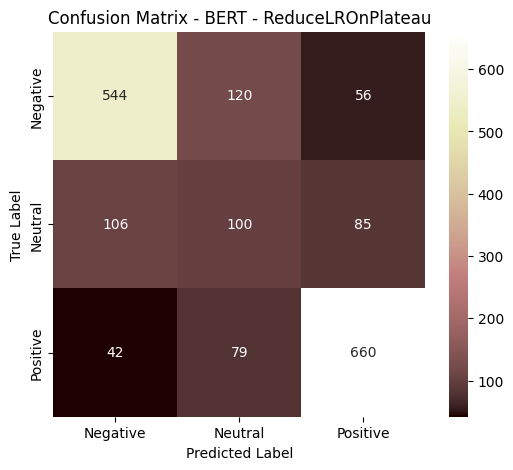

========== BERT - Gradient Clipping ==========

112/112 [==============================] - 6s 28ms/step
Accuracy  : 0.7411
Precision : 0.7149
Recall    : 0.7411
F1-Score  : 0.7252

Classification Report:

              precision    recall  f1-score   support

    Negative       0.77      0.81      0.79       720
     Neutral       0.33      0.22      0.26       291
    Positive       0.81      0.87      0.84       781

    accuracy                           0.74      1792
   macro avg       0.64      0.63      0.63      1792
weighted avg       0.71      0.74      0.73      1792



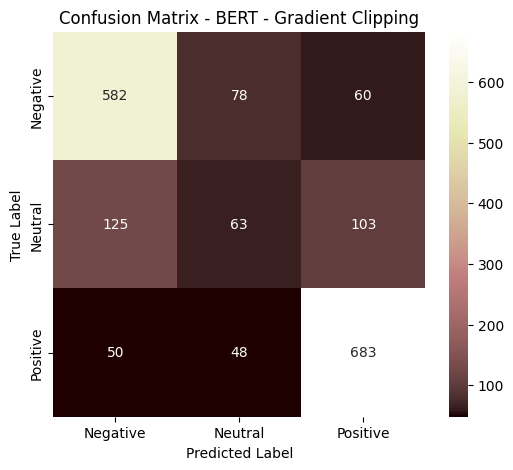

========== BERT - RMSprop Optimizer ==========

112/112 [==============================] - 6s 27ms/step
Accuracy  : 0.7294
Precision : 0.7243
Recall    : 0.7294
F1-Score  : 0.7191

Classification Report:

              precision    recall  f1-score   support

    Negative       0.71      0.90      0.79       720
     Neutral       0.33      0.24      0.28       291
    Positive       0.89      0.76      0.82       781

    accuracy                           0.73      1792
   macro avg       0.64      0.63      0.63      1792
weighted avg       0.72      0.73      0.72      1792



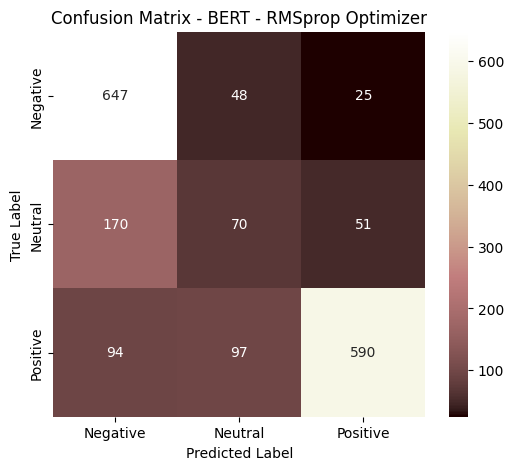

In [95]:
# Evaluate all improved models on the same emoji-preserved test set

improvement_results = []

improvement_results.append(
    evaluate_improved_model(
        class_weight_model,
        test_dataset,
        y_test_encoded,
        "BERT - Class Weight Balancing"
    )
)

improvement_results.append(
    evaluate_improved_model(
        batch_size_model,
        test_dataset,
        y_test_encoded,
        "BERT - Batch Size Tuning"
    )
)

improvement_results.append(
    evaluate_improved_model(
        learning_rate_model,
        test_dataset,
        y_test_encoded,
        "BERT - Learning Rate Tuning"
    )
)

improvement_results.append(
    evaluate_improved_model(
        early_stopping_model,
        test_dataset,
        y_test_encoded,
        "BERT - Early Stopping"
    )
)

improvement_results.append(
    evaluate_improved_model(
        dropout_model,
        test_dataset,
        y_test_encoded,
        "BERT - Dropout Regularization"
    )
)

improvement_results.append(
    evaluate_improved_model(
        reduce_lr_model,
        test_dataset,
        y_test_encoded,
        "BERT - ReduceLROnPlateau"
    )
)

improvement_results.append(
    evaluate_improved_model(
        clip_model,
        test_dataset,
        y_test_encoded,
        "BERT - Gradient Clipping"
    )
)

improvement_results.append(
    evaluate_improved_model(
        rmsprop_model,
        test_dataset,
        y_test_encoded,
        "BERT - RMSprop Optimizer"
    )
)

## Evaluation of the Max Sequence Length Model

========== BERT - Max Sequence Length ==========

112/112 [==============================] - 8s 42ms/step
Accuracy  : 0.7299
Precision : 0.6998
Recall    : 0.7299
F1-Score  : 0.7099

Classification Report:

              precision    recall  f1-score   support

    Negative       0.77      0.76      0.77       720
     Neutral       0.33      0.19      0.24       291
    Positive       0.77      0.90      0.83       781

    accuracy                           0.73      1792
   macro avg       0.62      0.62      0.61      1792
weighted avg       0.70      0.73      0.71      1792



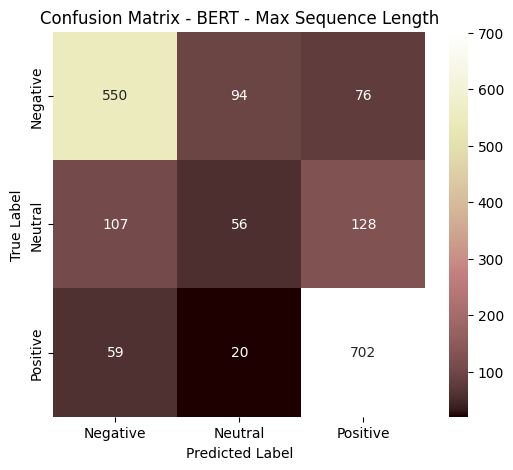

In [96]:
# Tokenize the test set using max_length=256 for the Max Sequence Length model

test_encodings_256 = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=256
)

test_dataset_256 = tf.data.Dataset.from_tensor_slices(
    dict(test_encodings_256)
).batch(16)

improvement_results.append(
    evaluate_improved_model(
        sequence_length_model,
        test_dataset_256,
        y_test_encoded,
        "BERT - Max Sequence Length"
    )
)

## Evaluation of the Learning Rate Scheduler Model

========== BERT - Learning Rate Scheduler ==========

112/112 [==============================] - 6s 27ms/step
Accuracy  : 0.7494
Precision : 0.7357
Recall    : 0.7494
F1-Score  : 0.7415

Classification Report:

              precision    recall  f1-score   support

    Negative       0.79      0.79      0.79       720
     Neutral       0.37      0.30      0.33       291
    Positive       0.82      0.88      0.85       781

    accuracy                           0.75      1792
   macro avg       0.66      0.66      0.66      1792
weighted avg       0.74      0.75      0.74      1792



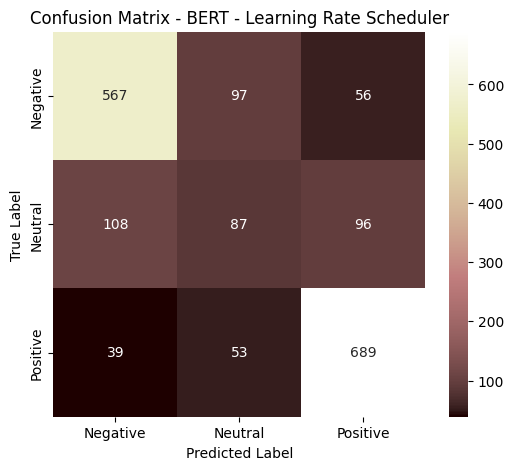

In [97]:
improvement_results.append(
    evaluate_improved_model(
        scheduler_model,
        test_dataset,
        y_test_encoded,
        "BERT - Learning Rate Scheduler"
    )
)

## Comparison of Improved Models

In [98]:
# Create a comparison table for all improved models

improvement_results_df = pd.DataFrame(improvement_results)

# Sort models by highest accuracy

improvement_results_df = improvement_results_df.sort_values(
    by='Accuracy',
    ascending=False
)

# Reset index

improvement_results_df = improvement_results_df.reset_index(drop=True)

# Display comparison table

print("Comparison of Improved BERT Models:\n")

improvement_results_df

Comparison of Improved BERT Models:



,Model,Accuracy,Precision,Recall,F1-Score
0,BERT - Dropout Regularization,0.753348,0.716463,0.753348,0.725844
1,BERT - Learning Rate Scheduler,0.749442,0.735732,0.749442,0.741508
2,BERT - Learning Rate Tuning,0.745536,0.698515,0.745536,0.698983
3,BERT - Early Stopping,0.744978,0.680601,0.744978,0.691404
4,BERT - Batch Size Tuning,0.742746,0.710066,0.742746,0.720271
5,BERT - Gradient Clipping,0.741071,0.714887,0.741071,0.725179
6,BERT - Max Sequence Length,0.729911,0.699820,0.729911,0.709941
7,BERT - RMSprop Optimizer,0.729353,0.724314,0.729353,0.719105
8,BERT - ReduceLROnPlateau,0.727679,0.729273,0.727679,0.728286
9,BERT - Class Weight Balancing,0.703683,0.739626,0.703683,0.718651


# Final Comparison Table


In [100]:
# Create a comparison table for all improved models sorted by highest F1-Score

improvement_results_by_f1 = pd.DataFrame(improvement_results)

improvement_results_by_f1 = improvement_results_by_f1.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

print("Comparison of Improved BERT Models Ranked by F1-Score:\n")

improvement_results_by_f1

Comparison of Improved BERT Models Ranked by F1-Score:



,Model,Accuracy,Precision,Recall,F1-Score
0,BERT - Learning Rate Scheduler,0.749442,0.735732,0.749442,0.741508
1,BERT - ReduceLROnPlateau,0.727679,0.729273,0.727679,0.728286
2,BERT - Dropout Regularization,0.753348,0.716463,0.753348,0.725844
3,BERT - Gradient Clipping,0.741071,0.714887,0.741071,0.725179
4,BERT - Batch Size Tuning,0.742746,0.710066,0.742746,0.720271
5,BERT - RMSprop Optimizer,0.729353,0.724314,0.729353,0.719105
6,BERT - Class Weight Balancing,0.703683,0.739626,0.703683,0.718651
7,BERT - Max Sequence Length,0.729911,0.699820,0.729911,0.709941
8,BERT - Learning Rate Tuning,0.745536,0.698515,0.745536,0.698983
9,BERT - Early Stopping,0.744978,0.680601,0.744978,0.691404
